In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anairamcosta/country-timeseries")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'country-timeseries' dataset.
Path to dataset files: /kaggle/input/country-timeseries


In [ ]:

import os
df = pd.read_csv(os.path.join(path, "country_timeseries.csv"))

In [ ]:
#Ordino le date dei casi dai più vecchi
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
121,2014-03-22,0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,2014-03-24,2,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,2014-03-25,3,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,2014-03-26,4,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,2014-03-27,5,103.0,8.0,6.0,NaN,NaN,NaN,NaN,NaN,66.0,6.0,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Scelgo un paese e ricavo i nuovi casi giornalieri
country = "Guinea"
df_seir_Gu = df [['Date', f'Cases_{country}', f'Deaths_{country}']].copy()
df_seir_Gu = df_seir_Gu.dropna()
df_seir_Gu["New_cases"] = df_seir_Gu["Cases_Guinea"].diff().fillna(0)

df_seir_Gu.head()

,Date,Cases_Guinea,Deaths_Guinea,New_cases
121,2014-03-22,49.0,29.0,0.0
120,2014-03-24,86.0,59.0,37.0
119,2014-03-25,86.0,60.0,0.0
118,2014-03-26,86.0,62.0,0.0
117,2014-03-27,103.0,66.0,17.0


Definisco equazioni SEIR:

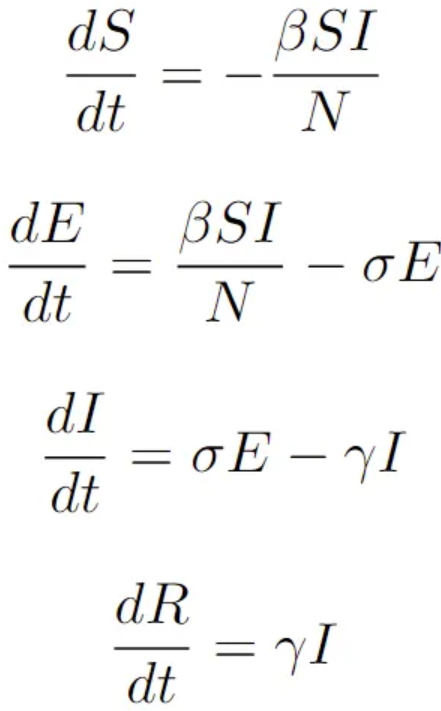



In [ ]:
#Definisce le ODE del sistema e fisso le condizioni iniziali, i parametri beta, gamma, sigma
#li fisso inizialmente

from scipy.integrate import odeint
import matplotlib.pyplot as plt

I_data = df_seir_Gu["Cases_Guinea"].values
t_model = np.linspace(0, 1000,1001 )  #tempo su cui valuto il modello
t_cal = np.arange(len(I_data)) #tempo su cui calibro il modello, compatibile
                              #con i dati del file
N = 10000000
beta  = 0.17    #tasso di trasmissione
sigma = 0.19    #incubazione 7 giorni
gamma = 0.1     #tempo di rimozione
f = 0.4         #mortalità

#Condizioni iniziali
I0 = 49
E0 = (gamma/sigma)*I0 # Esposti ma non ancora contagiosi e asintomatici
R0 = 0
S0 = N -I0-R0-E0
v = 0 #vaccinazione iniziale

y0 = S0, E0, I0, R0,


def seir_model(y, t, N, beta, sigma, gamma,v):
    S, E, I,  R = y
    dSdt =  -(beta*S*I)/N  -v*S
    dEdt = (beta*S*I)/N -sigma*E
    dIdt = sigma*E -gamma*I
    dRdt = (1-f)*gamma*I  +v*S
    return dSdt, dEdt, dIdt,  dRdt

ret = odeint(seir_model, y0, t_cal, args=(N, beta, sigma, gamma,v))
S, E, I,R = ret.T


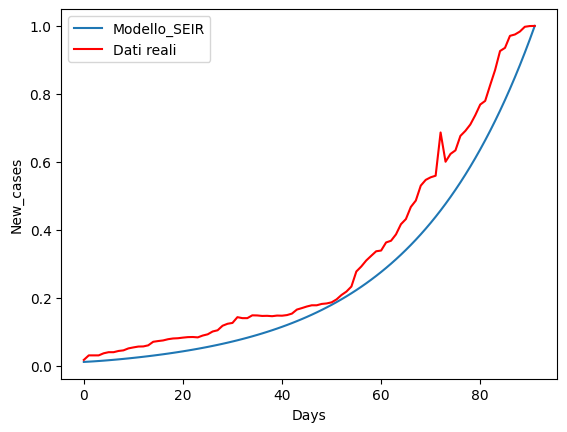

In [ ]:
plt.plot(t_cal, (I+R)/max(I+R), label='Modello_SEIR')
plt.plot(t_cal, I_data/max(I_data), label="Dati reali", color="red")
plt.xlabel('Days')
plt.ylabel('New_cases')
plt.legend()
plt.show()

In [ ]:
#Uso Non linear least Squares method per ottimizzare i parametri del mio modello
from scipy.optimize import minimize
bounds = [
    (1e-6,2.0), #Definisco limiti dei parametri beta
    (1e-6,1),   #sigma
    (1e-6,1)    #gamma
]


#Creo una funzione Sum Square Error che poi andrò a minimizzare
def sse (params):
  beta, sigma, gamma = params
  #Valuto il mio modello su tempi compatibili
  ret = odeint(seir_model, y0, t_cal, args=(N, beta, sigma, gamma,v))
  S, E, I,R = ret.T
  error = I_data - ((I+R))
  return np.sum(error**2)

In [ ]:
#minimizzo la funzione SSE per ottenere i parametri beta,sigma,gamma ottimizzati
result = minimize(
    sse,
    x0=[0.17, 0.19, 0.1],   # valori iniziali
    bounds=bounds

)

beta_opt,sigma_opt,gamma_opt = result.x

print("Best fit parameters:")
print("beta =", beta_opt)
print("sigma=", sigma_opt)
print("gamma =", gamma_opt)
print("R0 =", beta_opt/gamma_opt)

Best fit parameters:
beta = 0.09016434494846565
sigma= 0.9851984466762472
gamma = 0.05185768904389854
R0 = 1.7386880636377717


In [ ]:
#valuto bontà del modello
from sklearn.metrics import r2_score

# Ricostruisco il modello con i parametri ottimizzati
ret_opt = odeint(
    seir_model,
    y0,
    t_cal,
    args=(N,
          beta_opt,sigma_opt,gamma_opt,v)
)
S_opt, E_opt, I_opt,  R_opt = ret_opt.T

# Calcolo R2 con i risultati del modello ottimizzato
r2 = r2_score(I_data, I_opt + R_opt)

media residui = 0.6619292879211759


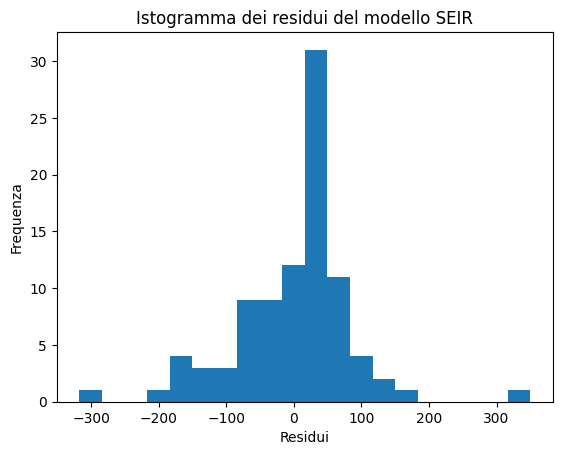

In [ ]:
residui = I_data - (I_opt + R_opt)
print("media residui =", np.mean(residui))
plt.hist(residui, bins=20)
plt.xlabel('Residui')
plt.ylabel('Frequenza')
plt.title('Istogramma dei residui del modello SEIR')
plt.show()


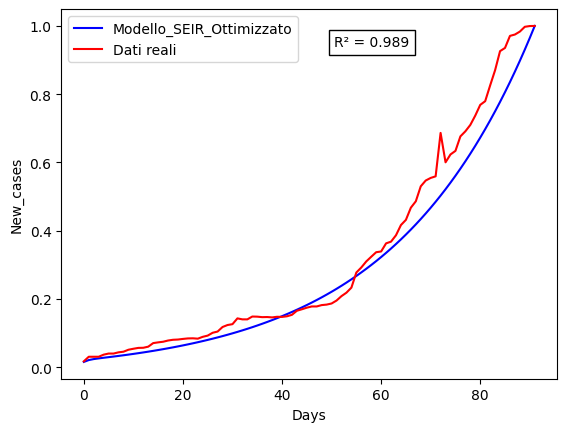

In [ ]:


plt.plot(t_cal, (I_opt+R_opt)/max(I_opt+R_opt), label='Modello_SEIR_Ottimizzato', color = 'blue')
plt.plot(t_cal, I_data /max(I_data) , label="Dati reali", color="red")
plt.text(
0.55, 0.90,
f'R² = {r2:.3f}',
transform=plt.gca().transAxes,
bbox=dict(facecolor='white', edgecolor='black')
)
plt.xlabel('Days')
plt.ylabel('New_cases')
plt.legend()
plt.show()

In [ ]:
#Valuto il mio modello su tempi lunghi
ret_t = odeint(
    seir_model,
    y0,
    t_model,
    args=(N,
          beta_opt,sigma_opt,gamma_opt,v)
)
S_t, E_t, I_t,  R_t = ret_t.T

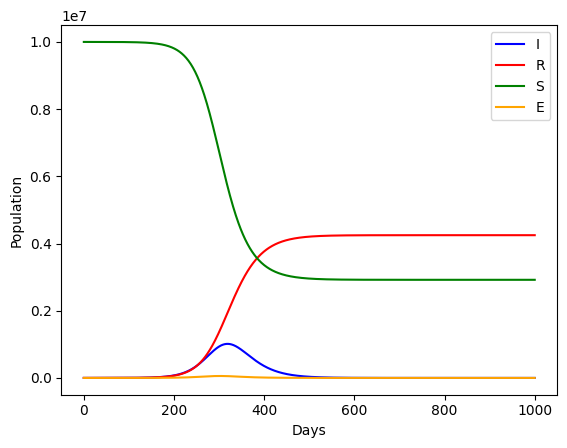

In [ ]:
plt.plot(t_model,I_t, label='I', color = 'blue')
plt.plot(t_model, R_t, label='R', color = 'red')
plt.plot(t_model, S_t, label='S', color = 'green')
plt.plot(t_model, E_t, label='E', color = 'orange')
plt.xlabel('Days')
plt.ylabel('Population')
plt.legend()
plt.show()

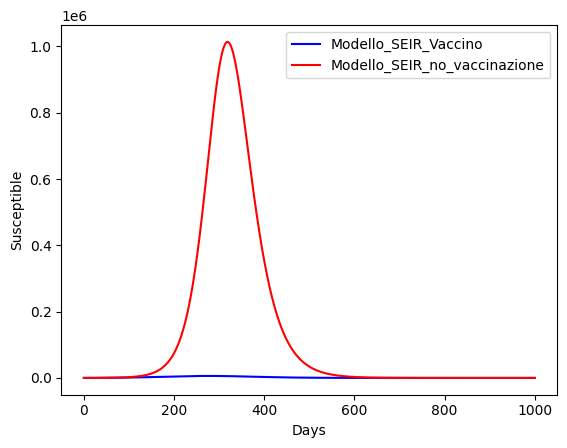

In [ ]:
#introduco una vaccinazione randomica  e confronto l'andamento dell' epidemia
#Per semplicità approssimo efficacia vaccino 100%

v = 0.002 #vaccino 0.2% dei suscettibili al giorno
ret_vax = odeint(
    seir_model,
    y0,
    t_model,
    args=(N,
          beta_opt,sigma_opt,gamma_opt,v)
)
S_vax, E_vax, I_vax,  R_vax = ret_vax.T
plt.plot(t_model, I_vax, label='Modello_SEIR_Vaccino',color = "blue")
plt.plot(t_model, I_t, label='Modello_SEIR_no_vaccinazione', color = "red")
plt.xlabel('Days')
plt.ylabel('Susceptible')
plt.legend()
plt.show()

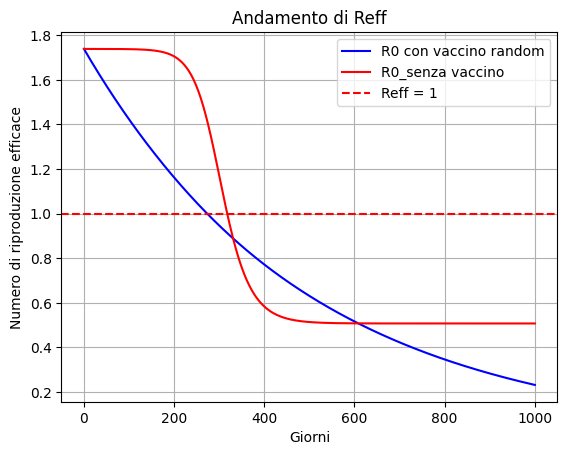

In [ ]:
#Calcolo numero di riproduzione
R0 = (beta_opt / gamma_opt)*S_vax/N
R0_no_vax = (beta_opt / gamma_opt)*S_t/N
plt.plot(t_model, R0,label = "R0 con vaccino random",color = 'blue')
plt.plot(t_model, R0_no_vax,label ="R0_senza vaccino",color ='red')
plt.axhline(y=1, color='r', linestyle='--', label='Reff = 1')
plt.xlabel('Giorni')
plt.ylabel('Numero di riproduzione efficace')
plt.title('Andamento di Reff')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Calcolo area sotto la il picco degli infetti
from numpy import trapezoid
auc_no_vax = trapezoid(I_t,t_model)
auc_vax = trapezoid(I_vax,t_model)
auc_reduction = (auc_no_vax - auc_vax)/auc_no_vax *100
print("AUC senza vaccinazione:", auc_no_vax)
print("AUC con vaccinazione:", auc_vax)
print("AUC riduzione:", auc_reduction)

AUC senza vaccinazione: 136527154.57991597
AUC con vaccinazione: 1503316.5660089531
AUC riduzione: 98.8988882316968


In [ ]:
###Simulo un modello in cui si applica una vaccinazione ai contatti degli infetti
def seir_model_ring(y, t, N, beta, sigma, gamma):
    S, E, I,  R = y
    #Le misure di tracciamento iniziano dopo 50 giorni
    if t <50:
      ring = 0
    else:
      c = 15  #contatti per caso
      p = 0.8 #80% contatti identificati
      ring = min(p*c*I,S)
    dSdt =  -(beta*S*I)/N  -ring
    dEdt = (beta*S*I)/N -sigma*E
    dIdt = sigma*E -gamma*I
    dRdt = (1-f)*gamma*I  + ring
    return dSdt, dEdt, dIdt,  dRdt

ret_ring = odeint(seir_model_ring, y0, t_model, args=(N, beta_opt, sigma_opt, gamma_opt))
S_r, E_r, I_r,R_r = ret_ring.T


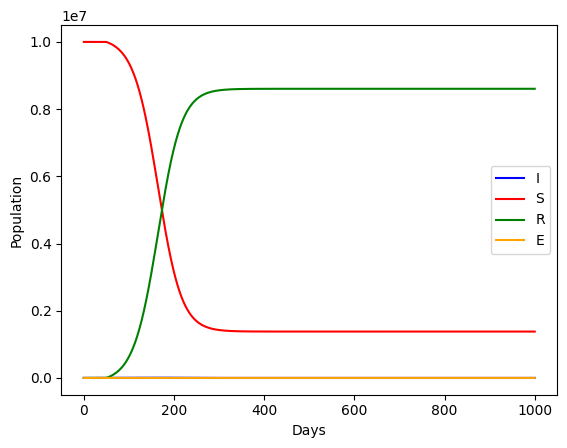

In [ ]:
plt.plot(t_model, I_r,label="I", color = "blue")
plt.plot(t_model,S_r,label="S", color = "red")
plt.plot(t_model,R_r, label = "R", color = "green")
plt.plot(t_model,E_r, label = "E", color = "orange")
plt.xlabel('Days')
plt.ylabel('Population')
plt.legend()
plt.show()

In [ ]:
auc_no_vax = trapezoid(I_t,t_model)
auc_ring = trapezoid(I_r,t_model)
auc_reduction = (auc_no_vax - auc_ring)/auc_no_vax *100
print("AUC senza vaccinazione:", auc_no_vax)
print("AUC con vaccinazione per target:", auc_ring)
print("AUC riduzione:", auc_reduction)

AUC senza vaccinazione: 136527154.57991597
AUC con vaccinazione per target: 724526.9679701173
AUC riduzione: 99.46931658379651


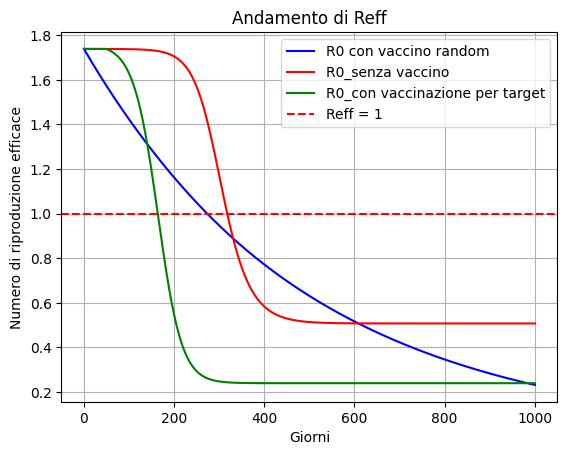

In [ ]:
#Calcolo numero di riproduzione
R0 = (beta_opt / gamma_opt)*S_vax/N
R0_r = (beta_opt / gamma_opt)*S_r/N
R0_no_vax = (beta_opt / gamma_opt)*S_t/N
plt.plot(t_model, R0,label = "R0 con vaccino random",color = 'blue')
plt.plot(t_model, R0_no_vax,label ="R0_senza vaccino",color ='red')
plt.plot(t_model, R0_r,label ="R0_con vaccinazione per target",color ='green')
plt.axhline(y=1, color='r', linestyle='--', label='Reff = 1')
plt.xlabel('Giorni')
plt.ylabel('Numero di riproduzione efficace')
plt.title('Andamento di Reff')
plt.legend()
plt.grid(True)
plt.show()